<a href="https://colab.research.google.com/github/princeiiitk/Smart_Segmentation_Unlocking_Customer_Personas/blob/main/5_Smart_Segmentation_Unlocking_Customer_Personas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation with Clustering

To use unsupervised machine learning to identify distinct groups of customers within a mall's dataset.

# Step1 :SetUp -Import Libraries and Loading dataset

In [62]:
from os import sched_get_priority_max
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [63]:
!git clone 'https://github.com/princeiiitk/Smart_Segmentation_Unlocking_Customer_Personas'

fatal: destination path 'Smart_Segmentation_Unlocking_Customer_Personas' already exists and is not an empty directory.


In [64]:
df=pd.read_csv('/content/Smart_Segmentation_Unlocking_Customer_Personas/Mall_Customers.csv')

In [65]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [66]:
df.shape

(200, 5)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [68]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [69]:
df.drop(columns=['CustomerID'],axis=1,inplace=True)

In [70]:
df.tail()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18
199,Male,30,137,83


# Univariate Analysis (Feature Distribution)

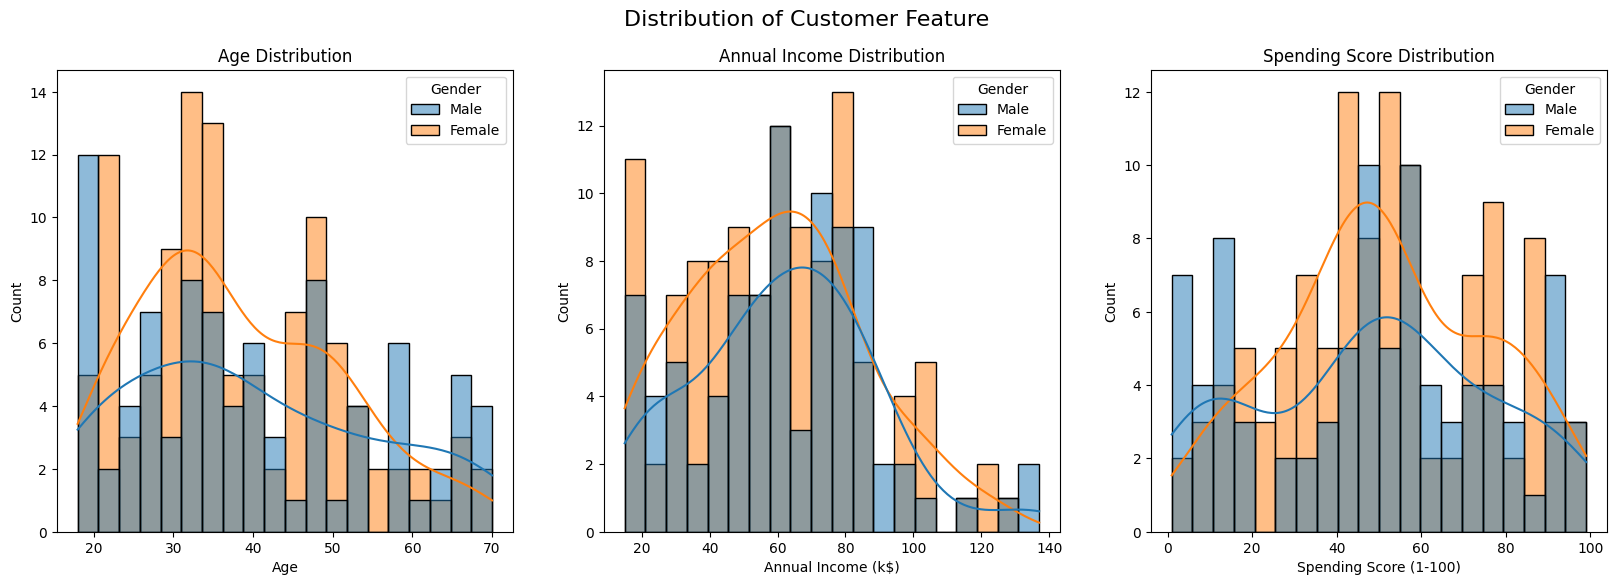

In [71]:
fig,axes=plt.subplots(1,3,figsize=(20,6))
fig.suptitle('Distribution of Customer Feature',fontsize=16)
sns.histplot(ax=axes[0],data=df,x='Age',kde=True,bins=20,hue='Gender').set_title("Age Distribution")
sns.histplot(ax=axes[1],data=df,x='Annual Income (k$)',kde=True,bins=20,hue='Gender').set_title("Annual Income Distribution")
sns.histplot(ax=axes[2],data=df,x='Spending Score (1-100)',kde=True,bins=20,hue='Gender').set_title("Spending Score Distribution")
#
plt.show()


# Bivariate Analysis (Looking for Relationships)

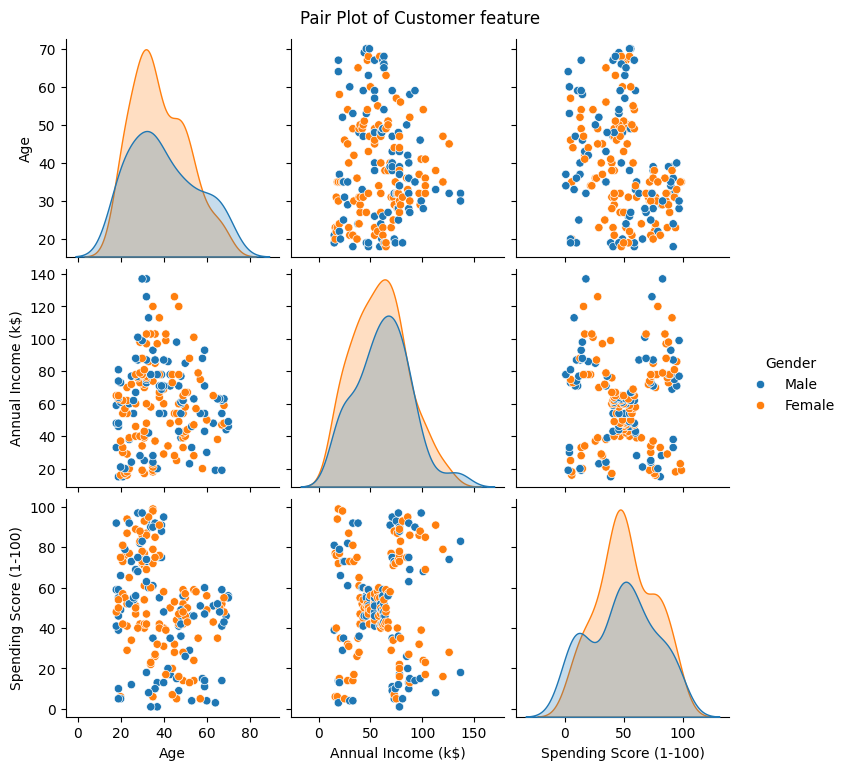

In [72]:
# using pairplot to visualize relationship between all numerical variables
sns.pairplot(df,vars=['Age','Annual Income (k$)','Spending Score (1-100)'],hue='Gender',diag_kind='kde')
plt.suptitle('Pair Plot of Customer feature',y=1.02)
plt.show()


In [73]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

**CRITICAL INSIGHT FROM Pair Plot**
The` Annual Income` vs `Spending score` plot the most reveling . it clearly show bob like group making, it the perfect candidate for clustering

The `age` vs `Spending score` plot show some pattern but they are less define . we see a concentration of high spending customer in the yunger age bracket

`Gender` does not appear to be a strong separating factor in any of these plots, as the distributions for males and females largely overlap.

In [74]:
fig =px.scatter_3d(df,
                   x='Annual Income (k$)',
                   y='Spending Score (1-100)',
                   z='Age',
                   color='Gender',
                   title='3D view of customer data')
fig.show()

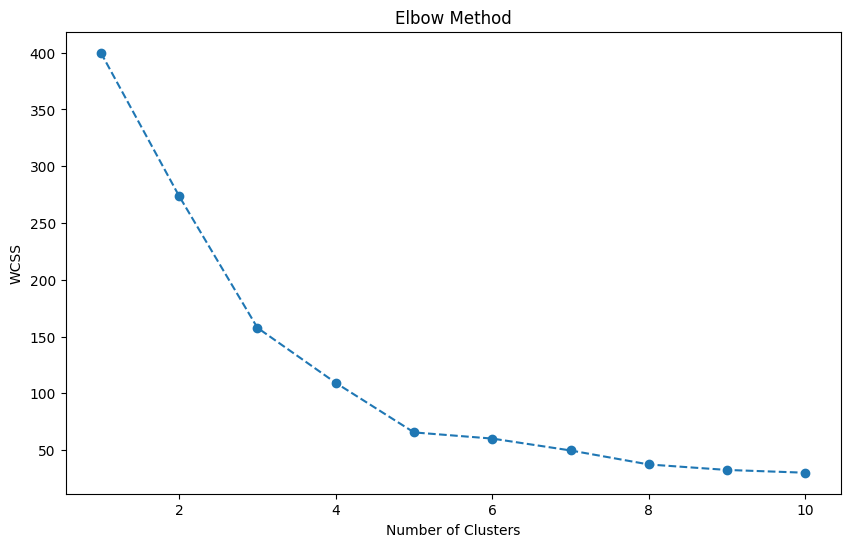

In [75]:
from matplotlib.lines import lineStyles
# select and scale the feature
x1=df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler=StandardScaler()
x1_scaled=scaler.fit_transform(x1)

# implement Elbow method
wcss=[]
for k in range(1,11):
  kmean=KMeans(n_clusters=k,random_state=42)
  kmean.fit(x1_scaled)
  wcss.append(kmean.inertia_)

# 3 plot the Elbow graph

plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

Observation: The "elbow" of the curve is clearly at k=5. The WCSS decreases sharply until k=5, and then the rate of decrease flattens out. This confirms our visual intuition from the scatter plot!

In [76]:
# Build and fit final model
kmeanf=KMeans(n_clusters=5,init='k-means++',random_state=42,n_init=10)
df['Income_cluster']=kmeanf.fit_predict(x1_scaled)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Income_cluster
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


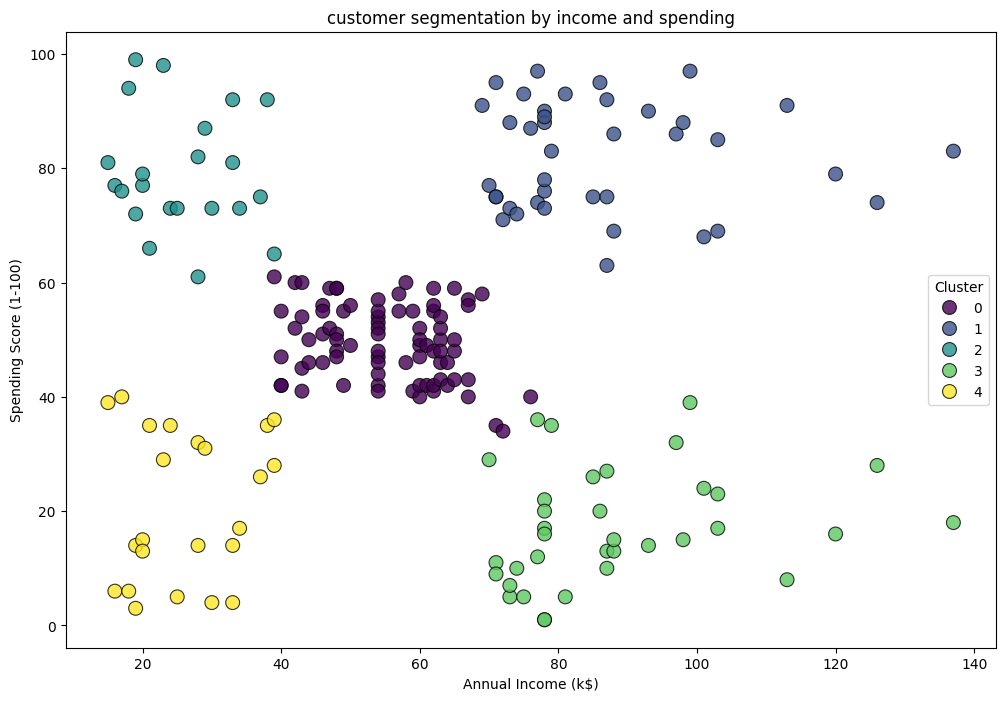

In [77]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='Income_cluster',palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.title('customer segmentation by income and spending')
plt.legend(title='Cluster')
plt.show()

In [78]:
# Quantitative Persona Analysis
cluster_profiles1=df.groupby('Income_cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(2)
# cluster_profiles1
cluster_profiles1['Size'] = df['Income_cluster'].value_counts()
print("--- Income-Based Cluster Profiles ---")
cluster_profiles1

--- Income-Based Cluster Profiles ---


,Age,Annual Income (k$),Spending Score (1-100),Size
Income_cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


3.2 Income-Based Personas and Strategy
Using the quantitative profiles, we can define our segments:

Cluster 0 (Careful High-Earners): High income (88k) but low spending (17). Cautious, value-driven buyers.  
Cluster 1 (Standard): Average income (55k) and spending (50). This is the largest, core customer group.  
Cluster 2 (Budget Shoppers): Low income (26k) and low spending (21). Highly price-sensitive.  
Cluster 3 (Target - High Value): High income (87k) and high spending (82). The mall's prime target.  
Cluster 4 (Enthusiasts): Low income (26k) but high spending (79). Likely young, trend-focused shoppers.

# Step 4: Segmentation Model 2 - Age & Spending Score
Let's create a different segmentation model to see if we can find age-related customer groups

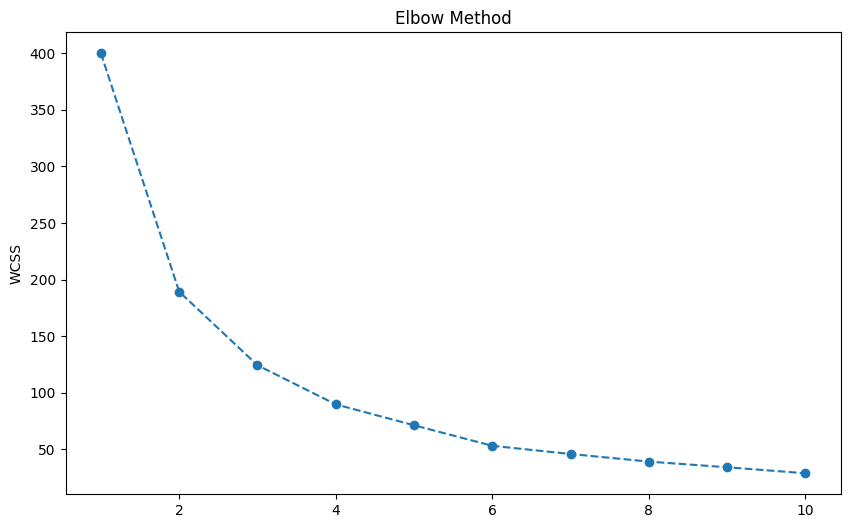

In [79]:
x2=df[['Age','Spending Score (1-100)']]
scaler=StandardScaler()
x2_scale=scaler.fit_transform(x2)
# find no. of cluster by using elbow method
wcss2=[]
for k2 in range(1,11):
  kmean2=KMeans(n_clusters=k2,init='k-means++',random_state=42,n_init=10)
  kmean2.fit(x2_scale)
  wcss2.append(kmean2.inertia_)

#elbow graph
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss2,marker='o',linestyle='--')
plt.title('Elbow Method for Age-Spending Segmentation')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

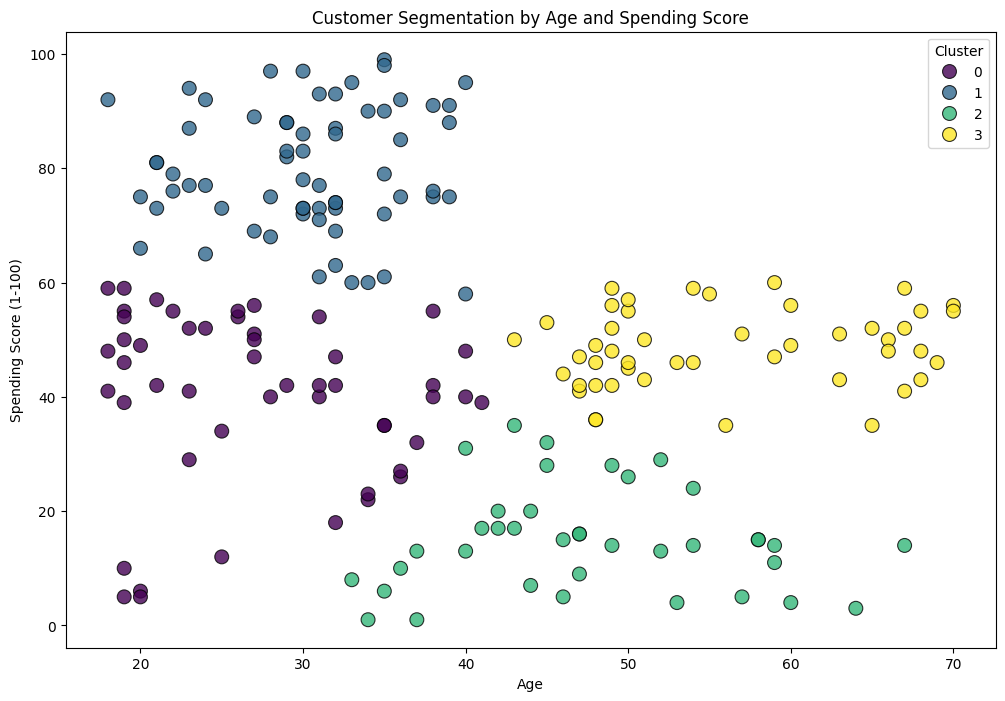

In [84]:
Kmeansf_age_spending=KMeans(n_clusters=4,init='k-means++',random_state=42,n_init=10)
df['Age_cluster']=Kmeansf_age_spending.fit_predict(x2_scale)
# labels=Kmeansf_age_spending.fit_predict(x2_scale)
# score = silhouette_score(x2_scale, labels)
# print(score)

# visualize the new cluster
plt.figure(figsize=(12,8))
sns.scatterplot(data=df,x='Age',y='Spending Score (1-100)',hue='Age_cluster',palette='viridis',s=100,alpha=0.8,edgecolor='black')
plt.title('Customer Segmentation by Age and Spending Score')
plt.legend(title='Cluster')
plt.show()

4.1 Interpreting the Age-Based Segments
This model gives us a different perspective:

Young High-Spenders: A clear group of customers under 40 with high spending scores.  
Young Low-Spenders: Customers under 40 with low-to-moderate spending.  
Older Average-Spenders: Customers over 40 with moderate spending scores.  
Older Low-Spenders: A small group of older customers with very low spending   scores.  


Unlike K-Means, Hierarchical Clustering doesn't require us to specify the number of clusters beforehand. It builds a tree-like hierarchy of clusters.

We can visualize this hierarchy with a dendrogram. The dendrogram shows how clusters are merged (or split). To find the optimal number of clusters, we look for the tallest vertical line that doesn't cross any horizontal lines and draw a horizontal line through it. The number of vertical lines our new line crosses is the optimal number of clusters.

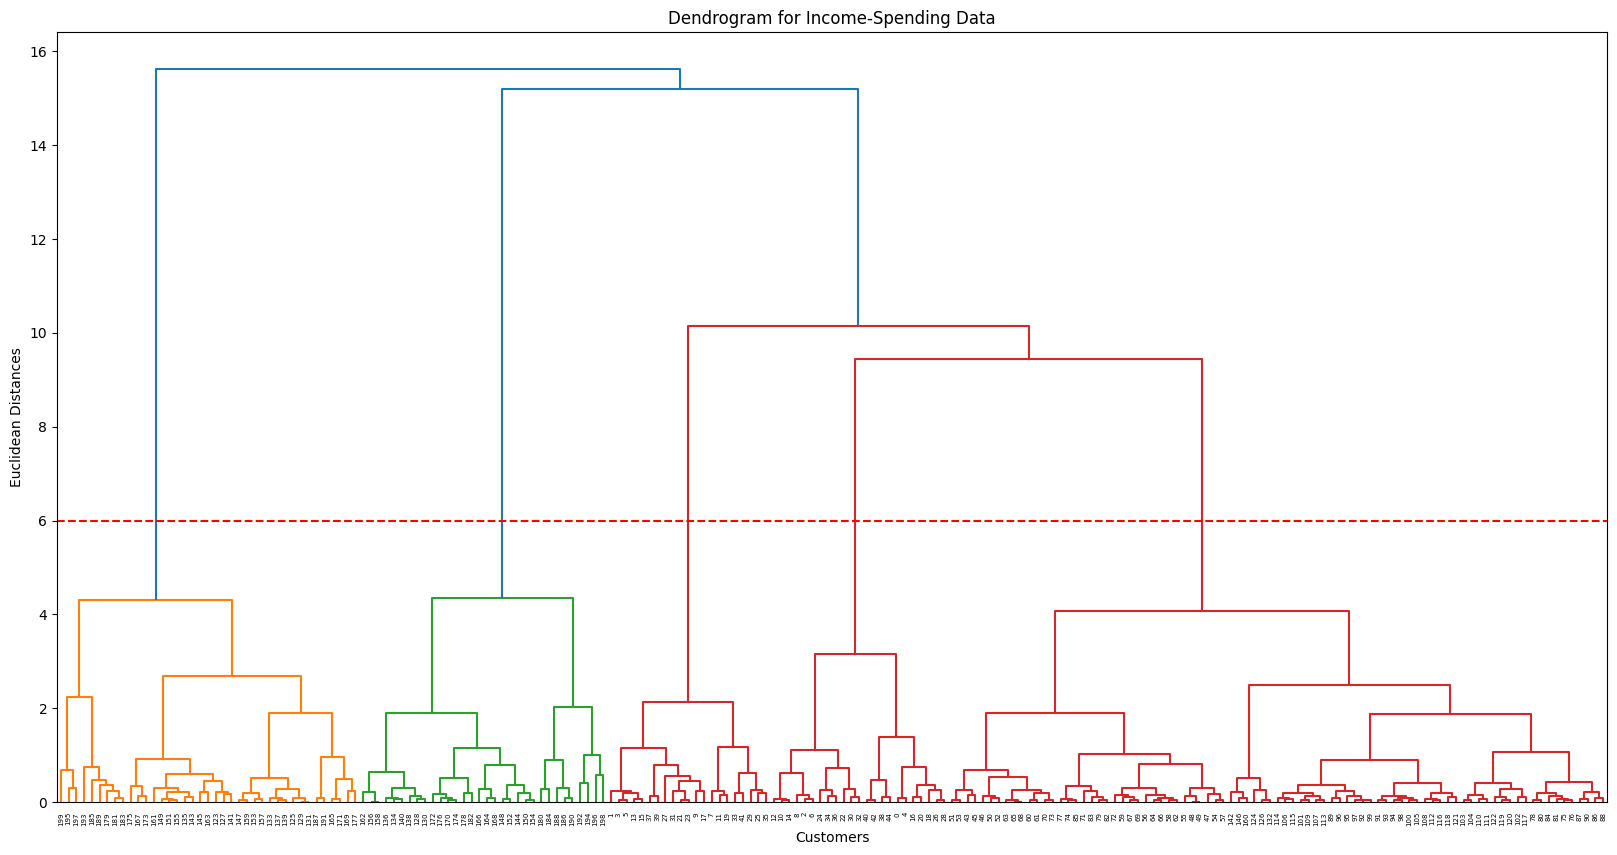

In [85]:
plt.figure(figsize=(20, 10))
dendrogram = sch.dendrogram(sch.linkage(x1_scaled, method='ward'))
plt.title('Dendrogram for Income-Spending Data')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distances')
plt.axhline(y=6, color='r', linestyle='--') # Example cut-off line
plt.show()